# Developing Sequence Models Using RNN, LSTM and GRU for Stock Market Price Predictions

In this notebook, we'll build and compare several recurrent neural network architectures for predicting stock prices:

- **Simple RNN** — baseline recurrent model
- **LSTM** (Long Short-Term Memory) — handles long-range dependencies
- **GRU** (Gated Recurrent Unit) — efficient alternative to LSTM
- **Stacked LSTM** — deeper architecture for complex patterns

We'll use **Apple (AAPL)** stock data loaded from a local Excel file (`AAPL_stock_data.xlsx`).

## 1. Setup & Imports

In [70]:
# Install required libraries (uncomment if needed)
# !pip install openpyxl tensorflow scikit-learn matplotlib seaborn pandas numpy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    SimpleRNN, LSTM, GRU, Dense, Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Plot style
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12
})
sns.set_palette('husl')

print(f'TensorFlow version: {tf.__version__}')
print('All libraries loaded successfully!')

TensorFlow version: 2.20.0
All libraries loaded successfully!


## 2. Data Loading from Excel

In [71]:
import pandas as pd

# --- Configuration ---
TICKER         = 'AAPL'
EXCEL_FILE     = 'AAPL_stock_data.xlsx'   # make sure extension is .xlsx
SEQ_LENGTH     = 60
FORECAST_STEPS = 30
TARGET_COL     = 'Close'

print(f"Loading data from '{EXCEL_FILE}' ...")

# --- Load Excel file ---
raw_multi = pd.read_excel(EXCEL_FILE, header=[0, 1], index_col=0)

# --- Flatten multi-level columns (if present) ---
if isinstance(raw_multi.columns, pd.MultiIndex):
    raw_multi.columns = raw_multi.columns.droplevel(1)

# --- Remove unwanted 'Date' row if it exists ---
if 'Date' in raw_multi.index:
    raw_multi = raw_multi.drop('Date')

# --- Convert index to datetime ---
raw_multi.index = pd.to_datetime(raw_multi.index, errors='coerce')

# --- Convert all data to numeric ---
raw_multi = raw_multi.apply(pd.to_numeric, errors='coerce')

# --- Drop missing values ---
raw_multi.dropna(inplace=True)

# --- Final DataFrame ---
raw = raw_multi.copy()

# --- Output ---
print(f"Loaded {len(raw)} trading days | {raw.index.min().date()} → {raw.index.max().date()}")
print(f"Columns: {list(raw.columns)}")
print()
print(raw.tail())

Loading data from 'AAPL_stock_data.xlsx' ...
Loaded 2515 trading days | 2015-01-02 → 2024-12-30
Columns: ['Close', 'High', 'Low', 'Open', 'Volume']

Price            Close        High         Low        Open    Volume
Date                                                                
2024-12-23  253.883118  254.261043  252.072998  253.385834  40858800
2024-12-24  256.797211  256.807136  253.903002  254.101927  23234700
2024-12-26  257.612732  258.686881  256.230300  256.787255  27237100
2024-12-27  254.201370  257.294489  251.685117  256.429191  42355300
2024-12-30  250.829788  252.122728  249.387669  250.859624  35557500


## 3. Exploratory Data Analysis

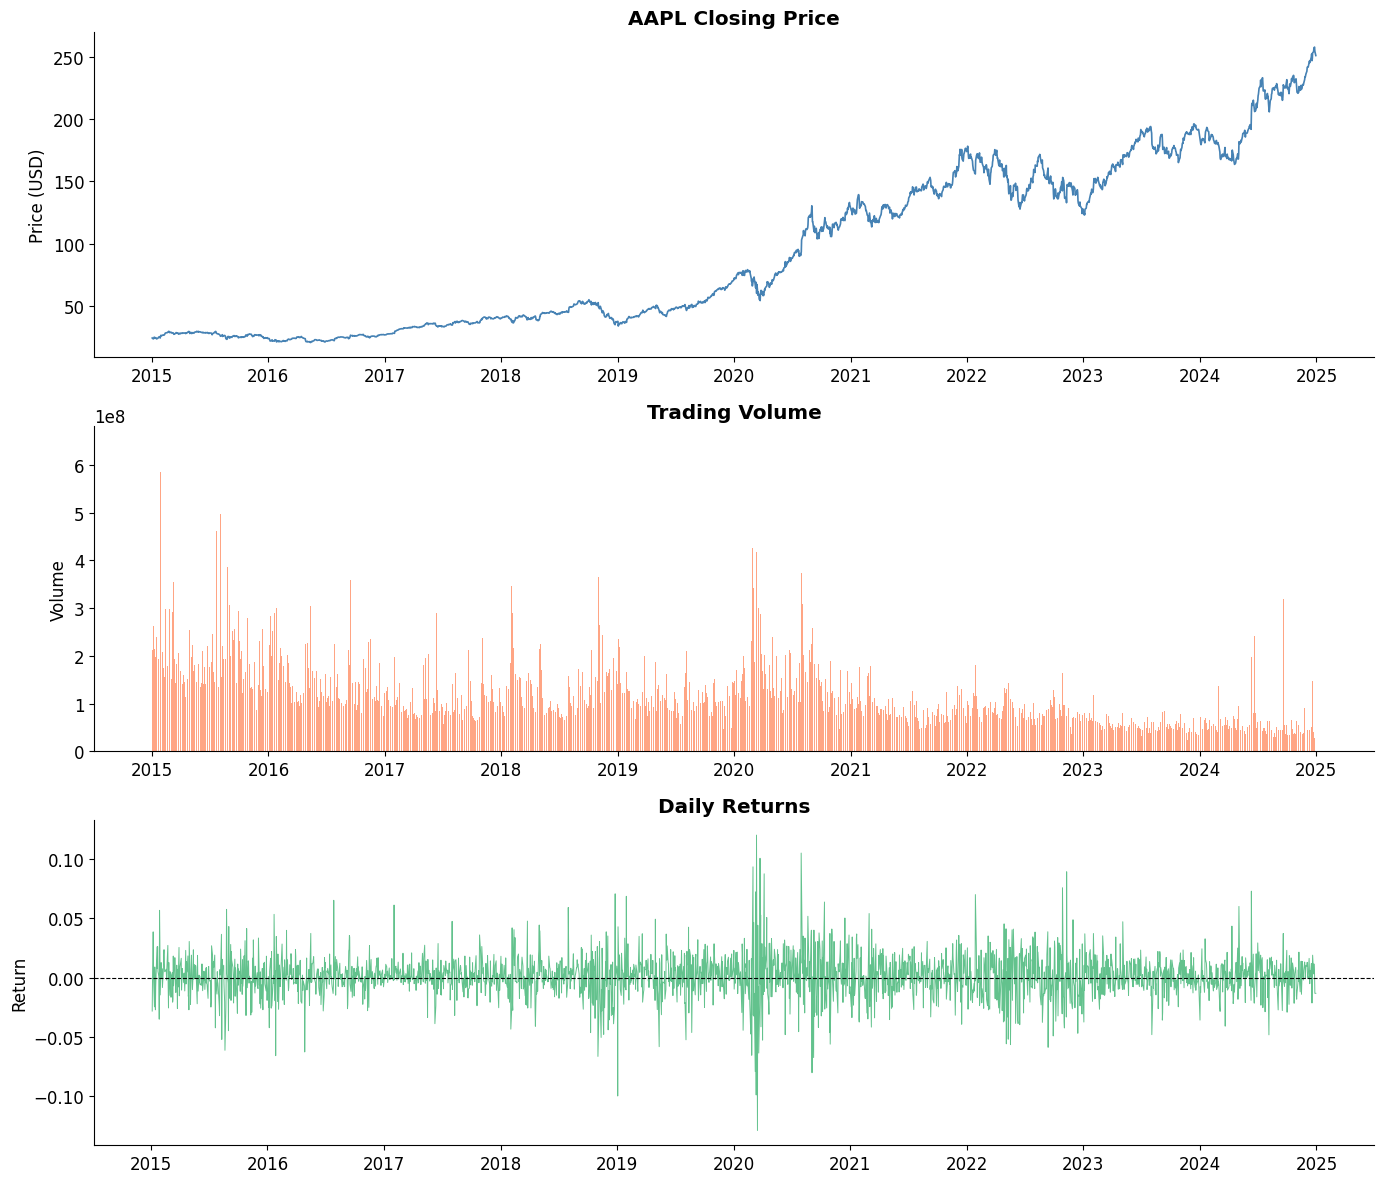


--- Summary Statistics ---
Price     Open     High      Low    Close        Volume
count  2515.00  2515.00  2515.00  2515.00  2.515000e+03
mean     93.62    94.62    92.70    93.71  1.171162e+08
std      65.24    65.91    64.63    65.32  6.839222e+07
min      20.51    20.89    20.39    20.58  2.323470e+07
25%      35.20    35.57    34.81    35.17  7.108655e+07
50%      64.07    64.66    63.51    64.31  1.003845e+08
75%     149.86   151.81   148.07   150.08  1.426222e+08
max     256.79   258.69   256.23   257.61  6.488252e+08


In [72]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Close price
axes[0].plot(raw.index, raw['Close'], color='steelblue', linewidth=1.2)
axes[0].set_title(f'{TICKER} Closing Price', fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Volume
axes[1].bar(raw.index, raw['Volume'], color='coral', alpha=0.7, width=1)
axes[1].set_title('Trading Volume', fontweight='bold')
axes[1].set_ylabel('Volume')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Daily returns
returns = raw['Close'].pct_change().dropna()
axes[2].plot(returns.index, returns, color='mediumseagreen', linewidth=0.7, alpha=0.8)
axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[2].set_title('Daily Returns', fontweight='bold')
axes[2].set_ylabel('Return')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.show()

print('\n--- Summary Statistics ---')
print(raw[['Open', 'High', 'Low', 'Close', 'Volume']].describe().round(2))

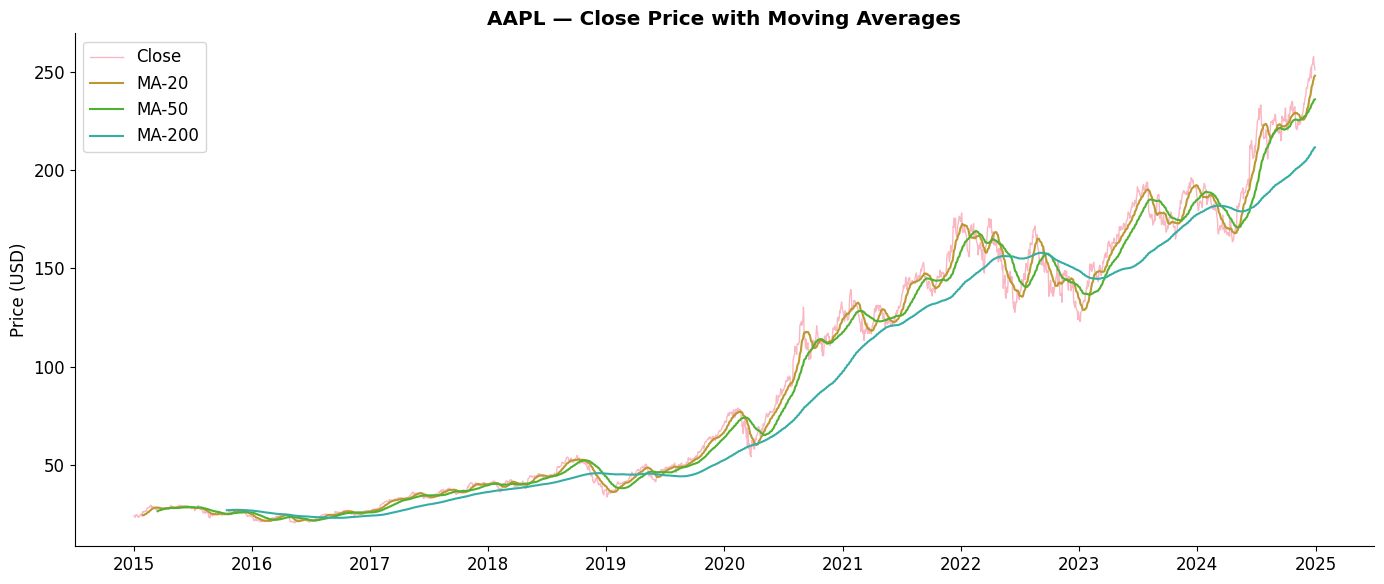

In [73]:
# Moving averages
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(raw.index, raw['Close'],                      label='Close',  alpha=0.5, linewidth=1)
ax.plot(raw.index, raw['Close'].rolling(20).mean(),   label='MA-20',  linewidth=1.5)
ax.plot(raw.index, raw['Close'].rolling(50).mean(),   label='MA-50',  linewidth=1.5)
ax.plot(raw.index, raw['Close'].rolling(200).mean(),  label='MA-200', linewidth=1.5)

ax.set_title(f'{TICKER} — Close Price with Moving Averages', fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [74]:
# Feature engineering
df = raw.copy()
df['MA_20']      = df['Close'].rolling(20).mean()
df['MA_50']      = df['Close'].rolling(50).mean()
df['Return']     = df['Close'].pct_change()
df['Volatility'] = df['Return'].rolling(20).std()
df['Volume_MA']  = df['Volume'].rolling(20).mean()
df.dropna(inplace=True)

print(f'Data shape after feature engineering: {df.shape}')
print(f'Features: {list(df.columns)}')

# Select features for modelling
FEATURES = ['Close', 'Volume', 'MA_20', 'MA_50', 'Return', 'Volatility']
data = df[FEATURES].values

# Train / Validation / Test split (70% / 15% / 15%)
n         = len(data)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_data = data[:train_end]
val_data   = data[train_end:val_end]
test_data  = data[val_end:]

print(f'\nTrain: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}')

# Scale (fit only on train)
scaler       = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_data)
val_scaled   = scaler.transform(val_data)
test_scaled  = scaler.transform(test_data)

# Separate scaler for the target (Close) — needed for inverse-transform of predictions
close_scaler = MinMaxScaler(feature_range=(0, 1))
close_scaler.fit(train_data[:, 0].reshape(-1, 1))

print('\nScaling complete.')

Data shape after feature engineering: (2466, 10)
Features: ['Close', 'High', 'Low', 'Open', 'Volume', 'MA_20', 'MA_50', 'Return', 'Volatility', 'Volume_MA']

Train: 1726 | Val: 370 | Test: 370

Scaling complete.


## 5. Building the Sequence Dataset

In [75]:
def create_sequences(data, seq_length, target_col=0):
    """
    Create sliding-window sequences.
    X: (n_samples, seq_length, n_features)
    y: (n_samples,)  — next-step value of target_col
    """
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i : i + seq_length])
        y.append(data[i + seq_length, target_col])
    return np.array(X), np.array(y)


# Build sequences over the full scaled array, then slice
full_scaled = np.vstack([train_scaled, val_scaled, test_scaled])

X_full, y_full = create_sequences(full_scaled, SEQ_LENGTH)

# Align split indices (sequences consume SEQ_LENGTH rows each)
train_size = train_end - SEQ_LENGTH
val_size   = val_end   - SEQ_LENGTH

X_train, y_train = X_full[:train_size],          y_full[:train_size]
X_val,   y_val   = X_full[train_size:val_size],  y_full[train_size:val_size]
X_test,  y_test  = X_full[val_size:],            y_full[val_size:]

print('Sequence shapes:')
print(f'  X_train: {X_train.shape}, y_train: {y_train.shape}')
print(f'  X_val:   {X_val.shape},   y_val:   {y_val.shape}')
print(f'  X_test:  {X_test.shape},  y_test:  {y_test.shape}')

Sequence shapes:
  X_train: (1666, 60, 6), y_train: (1666,)
  X_val:   (370, 60, 6),   y_val:   (370,)
  X_test:  (370, 60, 6),  y_test:  (370,)


## 6. Model Definitions

[![R1.png](https://i.postimg.cc/c4xcdLDZ/R1.png)](https://postimg.cc/MXLBDq2r)

ParamsRNN​=(input_dim×units)+(units×units)+units
Params𝐿𝑆𝑇𝑀=4×[(input_dim×units)+(units×units)+units]


In [76]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dropout, Dense
from tensorflow.keras.optimizers import Adam

def build_simple_rnn(input_shape):
    model = Sequential([
        SimpleRNN(64, input_shape=input_shape, return_sequences=True),
        Dropout(0.2),
        
        SimpleRNN(32),
        Dropout(0.2),
        
        Dense(16, activation='relu'),
        Dense(1)
    ], name='SimpleRNN')

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='mse',
        metrics=['mae']
    )
    
    return model


# Example usage:
INPUT_SHAPE = (60, 1)   # change if needed

model = build_simple_rnn(INPUT_SHAPE)
model.summary()

Model: "SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_16 (SimpleRNN)       │ (None, 60, 64)         │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_17 (SimpleRNN)       │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_28 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,873 (30.75 KB)

 Trainable params: 7,873 (30.75 KB)

 Non-trainable params: 0 (0.00 B)

INPUT_SHAPE = (SEQ_LENGTH, X_train.shape[2])

def build_simple_rnn(input_shape):
    model = Sequential([
        
    ], name='Simple_RNN')
    model.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])
    return model
build_simple_rnn(INPUT_SHAPE).summary()

[![R2.png](https://i.postimg.cc/GhfT6LVY/R2.png)](https://postimg.cc/D8qzXT2y)

In [78]:
def build_gru(input_shape):
    model = Sequential([
        GRU(64, input_shape=input_shape, return_sequences=True),
        Dropout(0.2),
        GRU(32),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ], name='GRU')

    
    model.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])

    return model

# Show summary
build_gru(INPUT_SHAPE).summary()

Model: "GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_11 (GRU)                    │ (None, 60, 64)         │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_12 (GRU)                    │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,817 (89.13 KB)

 Trainable params: 22,817 (89.13 KB)

 Non-trainable params: 0 (0.00 B)

In [79]:
def build_lstm(input_shape):
    model = Sequential([
      
    ], name='LSTM')
    model.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])
    return model
build_lstm(INPUT_SHAPE).summary()

Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

[![R3.png](https://i.postimg.cc/Fz3FqvLJ/R3.png)](https://postimg.cc/jnqrwGvs)

In [80]:

def build_gru(input_shape):
    model = Sequential([
    
    ], name='GRU')
    model.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])
    return model
build_gru(INPUT_SHAPE).summary()

Model: "GRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [86]:
[![R4.png](https://i.postimg.cc/767yPVZf/R4.png)](https://postimg.cc/2bzt2nvD)

SyntaxError: invalid decimal literal (3900588422.py, line 1)

In [83]:

def build_stacked_lstm(input_shape):
    model = Sequential([
   
    ], name='Stacked_LSTM')
    model.compile(optimizer=Adam(5e-4), loss='mse', metrics=['mae'])
    return model



build_stacked_lstm(INPUT_SHAPE).summary()

Model: "Stacked_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

[![GRU.png](https://i.postimg.cc/QdD4NPDY/GRU.png)](https://postimg.cc/8jyBtZjL)

## 7. Training & Evaluation

In [92]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense

def build_simple_rnn(input_shape):
    model = Sequential()
    model.add(SimpleRNN(32, input_shape=input_shape, name="simple_rnn_layer"))
    model.add(Dense(1, name="output_layer"))
    model.compile(optimizer='adam', loss='mse')
    return model


def build_lstm(input_shape):
    model = Sequential()
    model.add(LSTM(32, input_shape=input_shape, name="lstm_layer"))
    model.add(Dense(1, name="output_layer"))
    model.compile(optimizer='adam', loss='mse')
    return model


def build_gru(input_shape):
    model = Sequential()
    model.add(GRU(32, input_shape=input_shape, name="gru_layer"))
    model.add(Dense(1, name="output_layer"))
    model.compile(optimizer='adam', loss='mse')
    return model


def build_stacked_lstm(input_shape):
    model = Sequential()
    model.add(LSTM(32, return_sequences=True, input_shape=input_shape, name="lstm_1"))
    model.add(LSTM(16, name="lstm_2"))
    model.add(Dense(1, name="output_layer"))
    model.compile(optimizer='adam', loss='mse')
    return model

In [93]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

EPOCHS = 100
BATCH_SIZE = 64

# --- reshape ---
if len(X_train.shape) == 2:
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
    X_val   = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))

INPUT_SHAPE = (X_train.shape[1], X_train.shape[2])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=7)
]

model_builders = {
    'Simple_RNN': build_simple_rnn,
    'LSTM': build_lstm,
    'GRU': build_gru,
    'Stacked_LSTM': build_stacked_lstm
}

histories = {}
models = {}

for name, builder in model_builders.items():
    print(f"\nTraining: {name}")

    tf.keras.backend.clear_session()   # 🔥 CRITICAL FIX

    model = builder(INPUT_SHAPE)

    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )

    histories[name] = hist
    models[name] = model

print("✅ Done")


Training: Simple_RNN

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - loss: 0.0686 - val_loss: 0.0082 - learning_rate: 0.0010
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0056 - val_loss: 0.0125 - learning_rate: 0.0010
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0038 - val_loss: 0.0088 - learning_rate: 0.0010
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0029 - val_loss: 0.0083 - learning_rate: 0.0010
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0024 - val_loss: 0.0082 - learning_rate: 0.0010
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0020 - val_loss: 0.0081 - learning_rate: 0.0010
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0017 - val_loss: 0.0076 - learning_rate: 0.0010
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0014 - val_loss: 0.0065 - learning_rate: 0.0010
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0012 - val_loss: 0.0056 - learning_

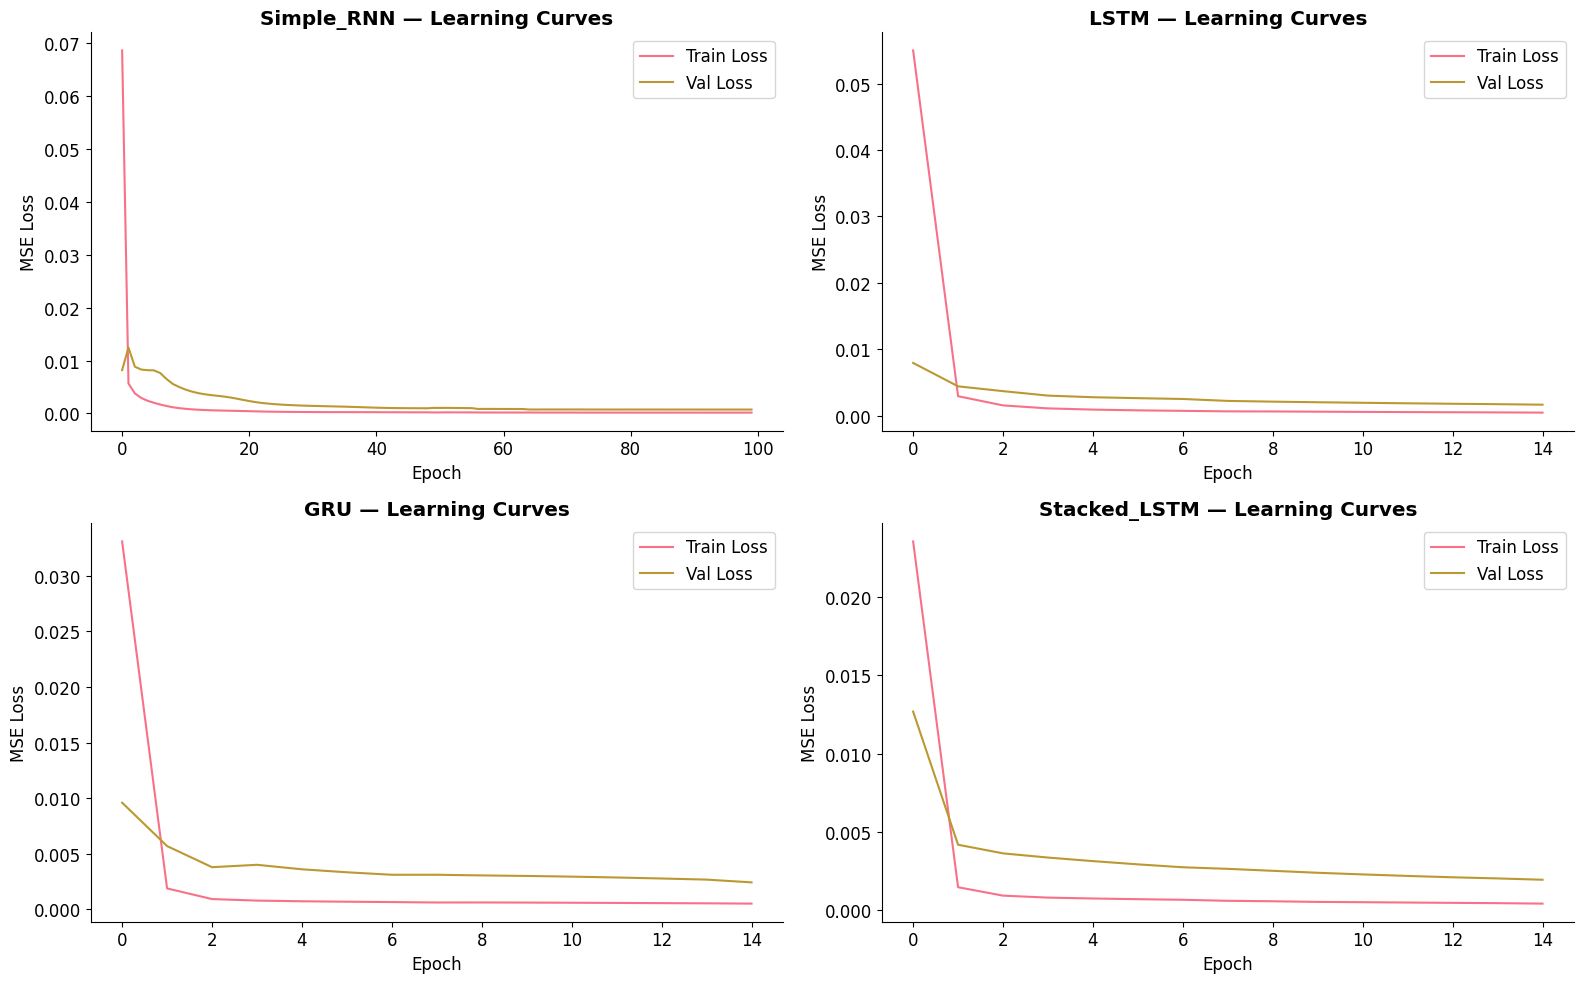

In [94]:
# Plot training curves
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, (name, hist) in zip(axes, histories.items()):
    ax.plot(hist.history['loss'],     label='Train Loss', linewidth=1.5)
    ax.plot(hist.history['val_loss'], label='Val Loss',   linewidth=1.5)
    ax.set_title(f'{name} — Learning Curves', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()

plt.tight_layout()
plt.show()

## 8. Predictions & Visualization

In [95]:
def evaluate_model(model, X, y_true_scaled):
    """Predict, inverse-transform, and compute metrics."""
    y_pred_scaled = model.predict(X, verbose=0).flatten()
    y_pred = close_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    y_true = close_scaler.inverse_transform(y_true_scaled.reshape(-1, 1)).flatten()

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    return y_pred, y_true, {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape}


# Evaluate all models on test set
results = {}
preds   = {}

for name, model in models.items():
    y_pred, y_true, metrics = evaluate_model(model, X_test, y_test)
    results[name] = metrics
    preds[name]   = (y_pred, y_true)

# Metrics table
results_df = pd.DataFrame(results).T.round(4)
print('\n--- Test Set Performance ---')
print(results_df.to_string())


--- Test Set Performance ---
                 RMSE      MAE      R2     MAPE
Simple_RNN     9.4430   7.1637  0.8481   3.3986
LSTM          37.1793  32.5354 -1.3546  15.6286
GRU           25.9194  23.2940 -0.1444  11.3687
Stacked_LSTM  17.3009  14.2638  0.4901   7.0033


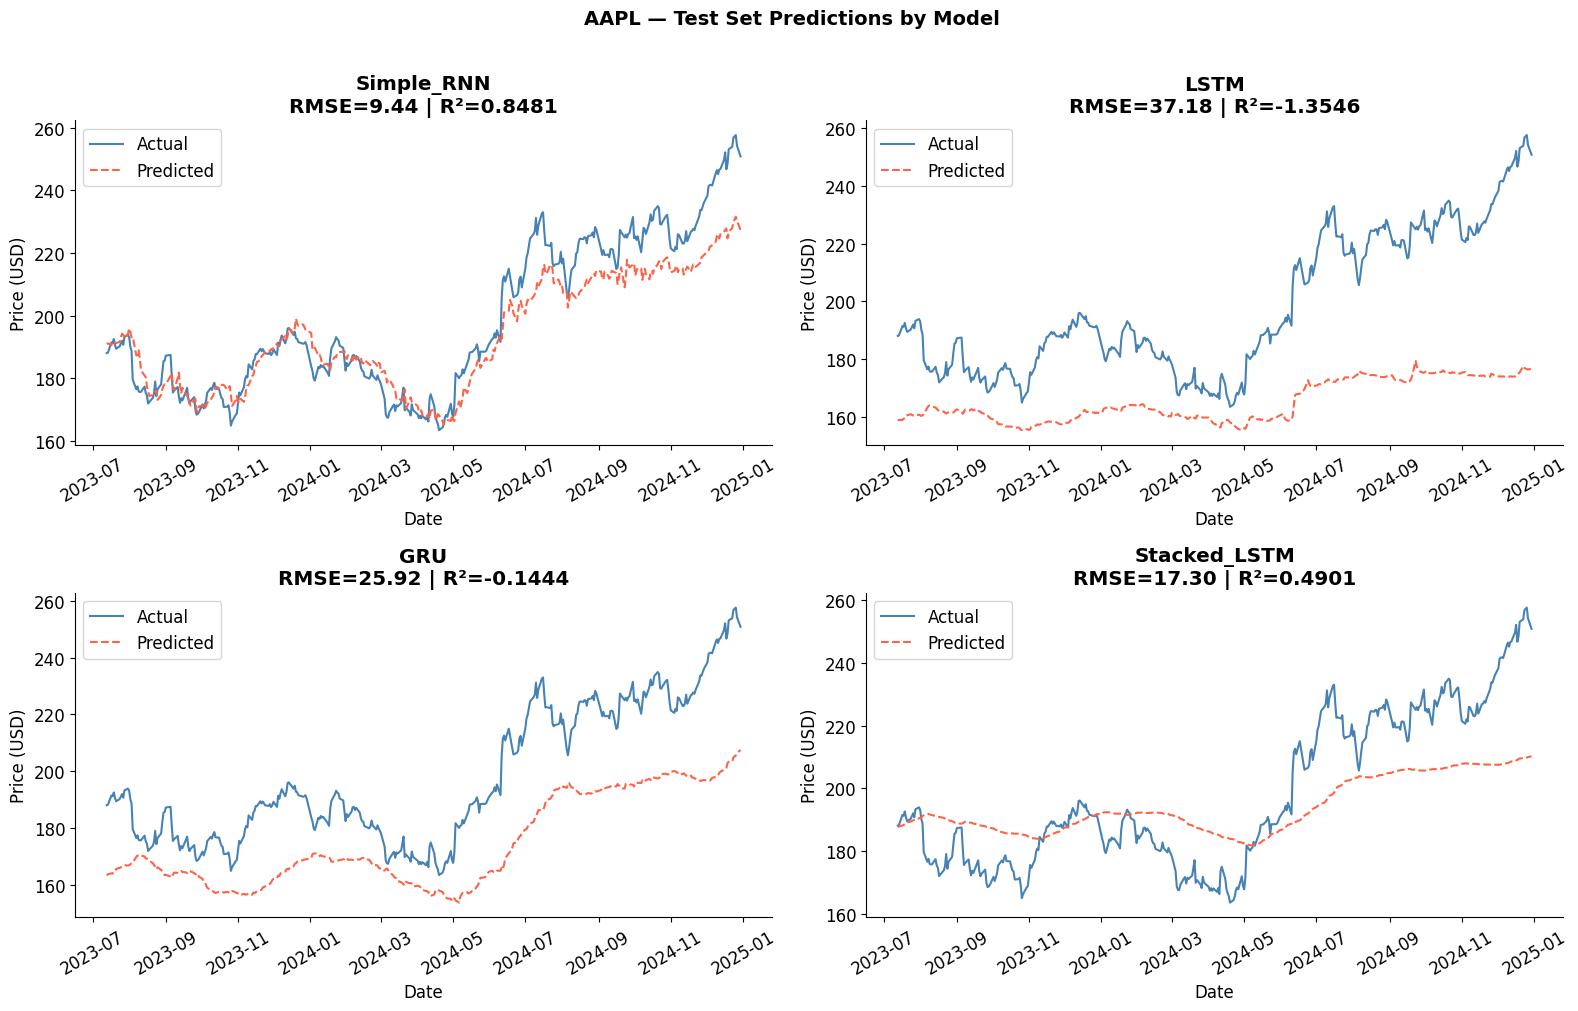

In [96]:
# Plot predictions vs actuals for each model
test_dates = df.index[val_end : val_end + len(y_test)]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, (name, (y_pred, y_true)) in zip(axes, preds.items()):
    ax.plot(test_dates, y_true, label='Actual',    linewidth=1.5, color='steelblue')
    ax.plot(test_dates, y_pred, label='Predicted', linewidth=1.5, color='tomato', linestyle='--')
    ax.set_title(f'{name}\nRMSE={results[name]["RMSE"]:.2f} | R\u00b2={results[name]["R2"]:.4f}',
                 fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price (USD)')
    ax.legend()
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=30)

plt.suptitle(f'{TICKER} — Test Set Predictions by Model', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 9. Model Comparison

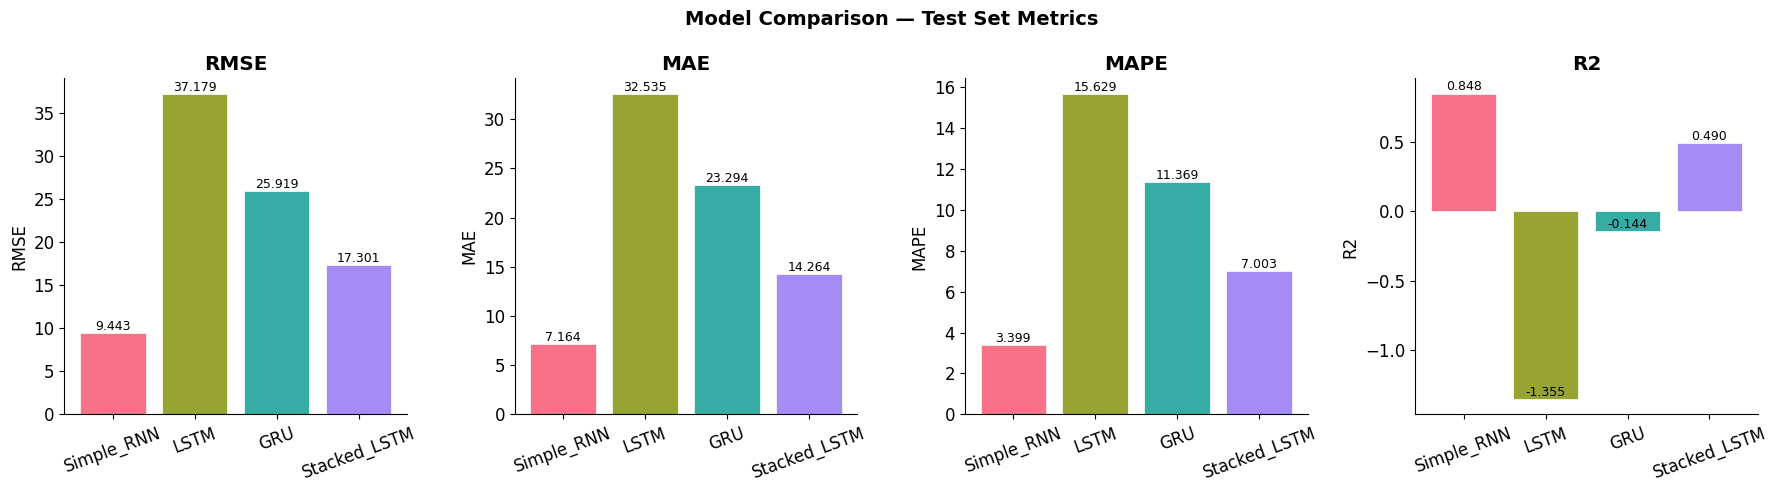


Best model by RMSE: Simple_RNN
RMSE    9.4430
MAE     7.1637
R2      0.8481
MAPE    3.3986
Name: Simple_RNN, dtype: float64


In [97]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

metrics_to_plot = ['RMSE', 'MAE', 'MAPE', 'R2']
colors = sns.color_palette('husl', len(results_df))

for ax, metric in zip(axes, metrics_to_plot):
    bars = ax.bar(results_df.index, results_df[metric], color=colors, edgecolor='white', linewidth=0.5)
    ax.set_title(metric, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Model Comparison — Test Set Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

best_model_name = results_df['RMSE'].idxmin()
print(f'\nBest model by RMSE: {best_model_name}')
print(results_df.loc[best_model_name])

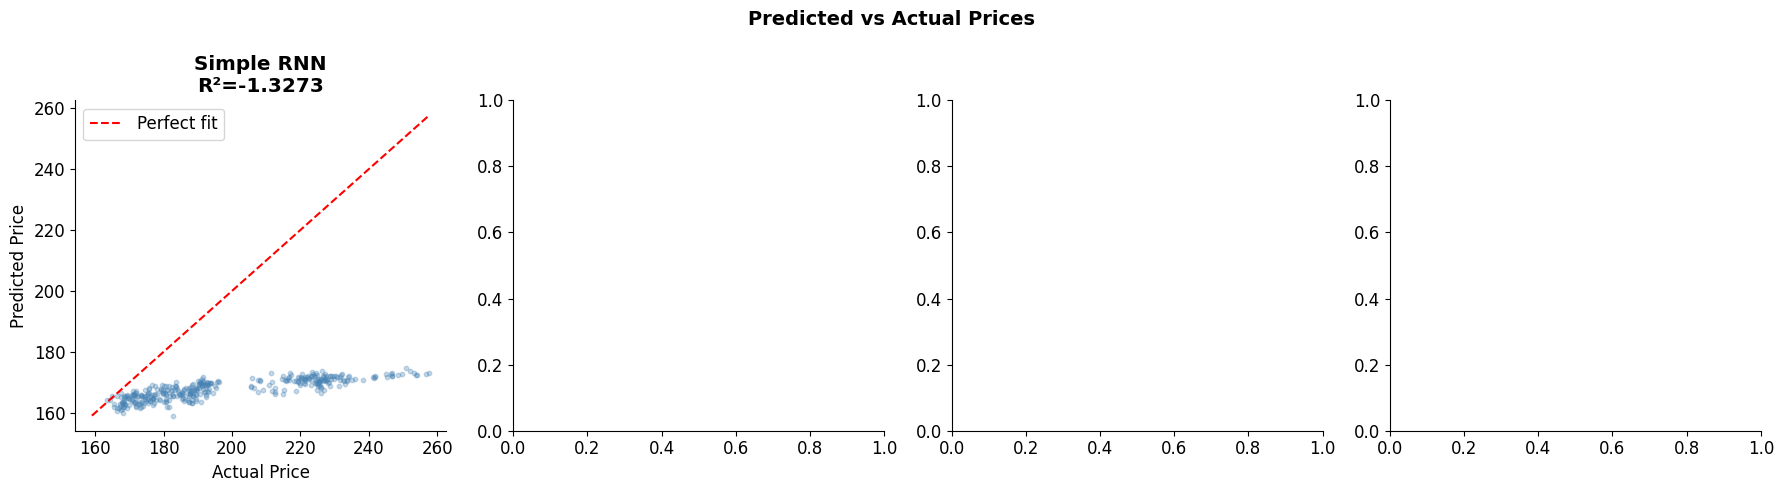

In [22]:
# Scatter: predicted vs actual for each model
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, (name, (y_pred, y_true)) in zip(axes, preds.items()):
    ax.scatter(y_true, y_pred, alpha=0.3, s=10, color='steelblue')
    lim = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lim, lim, 'r--', linewidth=1.5, label='Perfect fit')
    ax.set_title(f'{name}\nR\u00b2={results[name]["R2"]:.4f}', fontweight='bold')
    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')
    ax.legend()

plt.suptitle('Predicted vs Actual Prices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Future Forecasting

We'll use the best model to iteratively forecast the next `FORECAST_STEPS` trading days.

Forecasting with: Simple_RNN


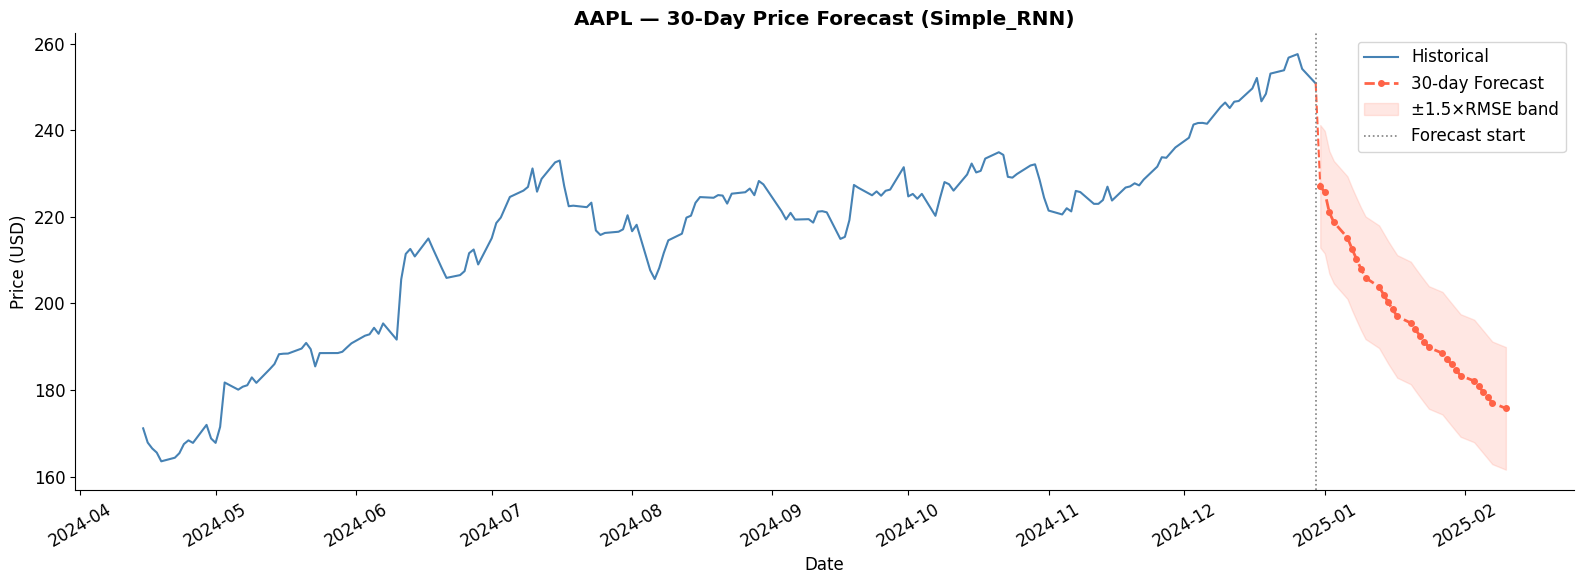


30-Day Forecast:
            Predicted_Close
Date                       
2024-12-31       227.059998
2025-01-01       225.710007
2025-01-02       221.059998
2025-01-03       218.770004
2025-01-06       215.210007
2025-01-07       212.639999
2025-01-08       210.279999
2025-01-09       207.990005
2025-01-10       205.929993
2025-01-13       203.850006
2025-01-14       202.050003
2025-01-15       200.250000
2025-01-16       198.610001
2025-01-17       197.000000
2025-01-20       195.479996
2025-01-21       194.000000
2025-01-22       192.570007
2025-01-23       191.179993
2025-01-24       189.820007
2025-01-27       188.490005
2025-01-28       187.179993
2025-01-29       185.889999
2025-01-30       184.610001
2025-01-31       183.339996
2025-02-03       182.080002
2025-02-04       180.820007
2025-02-05       179.559998
2025-02-06       178.300003
2025-02-07       177.029999
2025-02-10       175.750000


In [98]:
best_model = models[best_model_name]
print(f'Forecasting with: {best_model_name}')

# Seed sequence = last SEQ_LENGTH observations from full scaled dataset
full_scaled = np.vstack([train_scaled, val_scaled, test_scaled])
seed_seq    = full_scaled[-SEQ_LENGTH:].copy()   # (SEQ_LENGTH, n_features)

future_predictions = []
current_seq = seed_seq.copy()

for step in range(FORECAST_STEPS):
    x_input     = current_seq.reshape(1, SEQ_LENGTH, -1)
    pred_scaled = best_model.predict(x_input, verbose=0)[0, 0]
    future_predictions.append(pred_scaled)

    # Slide window: drop oldest row, append new step
    # Update only the Close column (index 0), keep other features constant
    new_row    = current_seq[-1].copy()
    new_row[0] = pred_scaled
    current_seq = np.vstack([current_seq[1:], new_row])

# Inverse transform
future_prices = close_scaler.inverse_transform(
    np.array(future_predictions).reshape(-1, 1)
).flatten()

# Generate future business dates
last_date    = df.index[-1]
future_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=FORECAST_STEPS)

# Plot
fig, ax = plt.subplots(figsize=(16, 6))

# Historical (last 180 days) — simple column access after Excel load
historical = df['Close'].iloc[-180:]
ax.plot(historical.index, historical.values, label='Historical', color='steelblue', linewidth=1.5)

# Connect history to forecast
ax.plot([last_date, future_dates[0]], [historical.iloc[-1], future_prices[0]],
        color='tomato', linewidth=1.5, linestyle='--')

# Forecast
ax.plot(future_dates, future_prices, label=f'{FORECAST_STEPS}-day Forecast',
        color='tomato', linewidth=2, linestyle='--', marker='o', markersize=4)

# Confidence band (±1.5 × test RMSE)
rmse = results[best_model_name]['RMSE']
ax.fill_between(future_dates,
                future_prices - 1.5 * rmse,
                future_prices + 1.5 * rmse,
                alpha=0.15, color='tomato', label='±1.5×RMSE band')

ax.axvline(last_date, color='gray', linestyle=':', linewidth=1.2, label='Forecast start')
ax.set_title(f'{TICKER} — {FORECAST_STEPS}-Day Price Forecast ({best_model_name})', fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (USD)')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

# Forecast table
forecast_df = pd.DataFrame({'Date': future_dates, 'Predicted_Close': future_prices.round(2)})
forecast_df.set_index('Date', inplace=True)
print(f'\n{FORECAST_STEPS}-Day Forecast:')
print(forecast_df.to_string())

## Summary

| Section | Key Takeaways |
|---------|---------------|
| **Data** | Loaded multi-year OHLCV data from local Excel file (`AAPL_stock_data.xlsx`); engineered MA, return, and volatility features |
| **Sequence Design** | 60-day look-back windows; 6 input features; predict next-day close |
| **Simple RNN** | Lightweight, prone to vanishing gradients on long sequences |
| **LSTM** | Handles long-range dependencies via gating mechanisms |
| **GRU** | Slightly fewer parameters than LSTM; often comparable accuracy |
| **Stacked LSTM** | Deepest model; best for capturing multi-scale temporal patterns |
| **Evaluation** | RMSE, MAE, MAPE, R² computed on held-out test set |
| **Forecasting** | Iterative multi-step forecast with uncertainty band |

---

> ⚠️ **Disclaimer:** This notebook is for educational purposes only. Stock price forecasts from these models should **not** be used for real investment decisions. Financial markets are driven by many factors that sequence models cannot fully capture.